# Exploratory Data Analysis — Bankruptcy Prevention Dataset

**Project:** Bankruptcy Prevention (Binary Classification)
**Dataset:** `bankrupt.csv` — 250 companies, 6 qualitative predictors + 1 target
**Objective:** Model the probability that a company goes bankrupt using six risk/flexibility indicators, each scored as `0` (low), `0.5` (medium), or `1` (high).

| Feature | Meaning |
|---|---|
| `industrial_risk` | 0 = low risk, 0.5 = medium risk, 1 = high risk |
| `management_risk` | 0 = low risk, 0.5 = medium risk, 1 = high risk |
| `financial_flexibility` | 0 = low flexibility, 0.5 = medium, 1 = high flexibility |
| `credibility` | 0 = low credibility, 0.5 = medium, 1 = high credibility |
| `competitiveness` | 0 = low competitiveness, 0.5 = medium, 1 = high |
| `operating_risk` | 0 = low risk, 0.5 = medium risk, 1 = high risk |
| `class` | Target: `bankruptcy` / `non-bankruptcy` |

---
This notebook walks through a complete, professional EDA workflow: every step includes **why** it is performed before the code that performs it.


## Step 1 — Import Libraries

**Why:** Every EDA workflow needs a data-handling library (`pandas`), numerical support (`numpy`), and visualization libraries (`matplotlib`, `seaborn`). Importing everything up front keeps the workflow reproducible and avoids scattered imports later in the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings

warnings.filterwarnings('ignore')

# Global plotting style — consistent, professional look throughout the notebook
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')
sns.set_palette('Set2')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Step 2 — Load the Dataset

**Why:** Before any analysis, we must load the raw file correctly. This file is **semicolon-delimited** (`sep=';'`), a common convention in European-format CSV exports, rather than the default comma. Reading it with the wrong separator would silently collapse all 7 columns into one — pandas would not raise an error, so this is the first thing to verify with any unfamiliar file.

In [2]:

df = pd.read_csv('Bankruptcy_prevention_Dataset.csv', sep=';')
df.head()


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy


## Step 3 — Clean Column Names

**Why:** Column headers in the raw file contain leading whitespace (e.g. `" management_risk"`), inherited from spaces after the semicolon delimiters. Untrimmed names cause `KeyError`s when referencing columns later and make output harder to read, so we standardize them immediately after loading.

In [3]:
print("Before cleaning:", df.columns.tolist())
df.columns = df.columns.str.strip()
print("After cleaning: ", df.columns.tolist())


Before cleaning: ['industrial_risk', ' management_risk', ' financial_flexibility', ' credibility', ' competitiveness', ' operating_risk', ' class']
After cleaning:  ['industrial_risk', 'management_risk', 'financial_flexibility', 'credibility', 'competitiveness', 'operating_risk', 'class']


## Step 4 — Check Dataset Shape

**Why:** A basic sanity check to confirm the correct file loaded, and that it matches the business brief (250 companies, 7 columns), before deeper analysis begins.

In [4]:
print(f"Rows (companies):        {df.shape[0]}")
print(f"Columns (features+target): {df.shape[1]}")


Rows (companies):        250
Columns (features+target): 7


## Step 5 — Preview the Data (head / tail / random sample)

**Why:** Looking at the first rows, last rows, and a random sample helps catch structural issues (e.g. the file being sorted by class, trailing junk rows, or inconsistent formatting) that a summary statistic alone would not reveal.

In [5]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nRandom sample of 5 rows:")
display(df.sample(5, random_state=42))


First 5 rows:


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy



Last 5 rows:


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy
249,1.0,0.0,0.5,0.5,1.0,1.0,non-bankruptcy



Random sample of 5 rows:


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
142,0.0,1.0,1.0,1.0,0.5,1.0,non-bankruptcy
6,1.0,1.0,0.0,0.0,0.0,0.0,bankruptcy
97,1.0,1.0,0.0,0.5,0.0,0.5,bankruptcy
60,0.0,1.0,0.0,0.0,0.0,0.0,bankruptcy
112,0.5,0.5,1.0,1.0,1.0,0.5,non-bankruptcy


## Step 6 — Inspect Data Types & Structure

**Why:** Statistics and correlation calculations only work correctly on numeric columns. Confirming dtypes before analysis avoids silent errors — e.g. calling `.describe()` on a text column, or treating numbers accidentally stored as strings.

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [7]:
dtype_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
})
dtype_summary


,dtype,n_unique
industrial_risk,float64,3
management_risk,float64,3
financial_flexibility,float64,3
credibility,float64,3
competitiveness,float64,3
operating_risk,float64,3
class,object,2


## Step 7 — Missing Values Analysis

**Why:** Missing data can bias a model or crash training. We must quantify it precisely — count, percentage, and pattern — before deciding on an imputation/drop strategy. A missingness **heatmap** additionally reveals whether any missing values follow a pattern (e.g. concentrated in certain rows/columns) rather than being scattered randomly.

In [8]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct (%)': missing_pct
}).sort_values('missing_count', ascending=False)

print("Missing value summary:")
display(missing_summary)

total_missing = missing_count.sum()
print(f"\nTotal missing cells in dataset: {total_missing}")
print(f"Total cells in dataset:         {df.size}")
print(f"Overall missing rate:           {total_missing / df.size * 100:.2f}%")


Missing value summary:


,missing_count,missing_pct (%)
industrial_risk,0,0.0
management_risk,0,0.0
financial_flexibility,0,0.0
credibility,0,0.0
competitiveness,0,0.0
operating_risk,0,0.0
class,0,0.0



Total missing cells in dataset: 0
Total cells in dataset:         1750
Overall missing rate:           0.00%


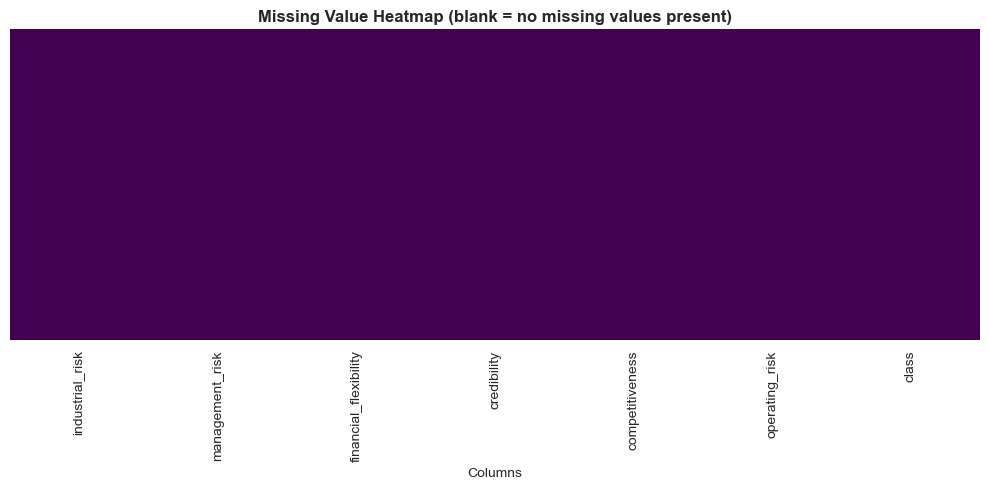

In [9]:
# Visual missingness check — a fully yellow/blank heatmap confirms no missing data
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (blank = no missing values present)')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()


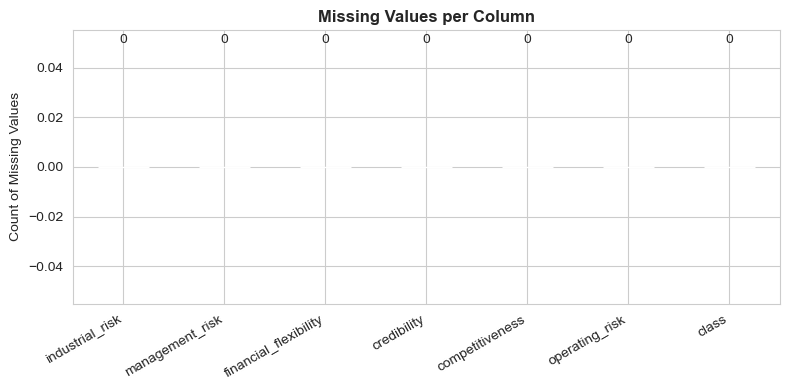

In [10]:
# Bar chart view of missing values per column
plt.figure(figsize=(8, 4))
ax = missing_summary['missing_count'].plot(kind='bar', color='indianred')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(missing_summary['missing_count']):
    ax.text(i, v + 0.05, str(v), ha='center')
plt.tight_layout()
plt.show()


## Step 8 — Duplicate Rows Analysis

**Why:** Duplicate records can inflate certain patterns and cause data leakage if identical rows land in both the train and test split later. We check thoroughly: how many, which ones, and how they break down by class — not just a single count — so we can make an informed decision about whether to drop them before modeling.

In [11]:
n_duplicates = df.duplicated().sum()
n_unique_rows = len(df) - n_duplicates

print(f"Total rows:              {len(df)}")
print(f"Duplicate rows:          {n_duplicates}  ({n_duplicates/len(df)*100:.1f}%)")
print(f"Unique rows:             {n_unique_rows}  ({n_unique_rows/len(df)*100:.1f}%)")


Total rows:              250
Duplicate rows:          147  (58.8%)
Unique rows:             103  (41.2%)


In [12]:
# Show a sample of duplicated rows (all occurrences, not just repeats after the first)
dup_mask = df.duplicated(keep=False)
print(f"Rows involved in duplication (all occurrences): {dup_mask.sum()}")
print("\nSample of duplicated rows, grouped together:")
display(df[dup_mask].sort_values(list(df.columns)).head(12))


Rows involved in duplication (all occurrences): 221

Sample of duplicated rows, grouped together:


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
107,0.0,0.0,0.5,0.5,0.5,0.0,non-bankruptcy
215,0.0,0.0,0.5,0.5,0.5,0.0,non-bankruptcy
116,0.0,0.0,0.5,0.5,1.0,0.0,non-bankruptcy
224,0.0,0.0,0.5,0.5,1.0,0.0,non-bankruptcy
180,0.0,0.0,0.5,0.5,1.0,1.0,non-bankruptcy
207,0.0,0.0,0.5,0.5,1.0,1.0,non-bankruptcy
115,0.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy
223,0.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy
113,0.0,0.0,0.5,1.0,1.0,0.0,non-bankruptcy
178,0.0,0.0,0.5,1.0,1.0,0.0,non-bankruptcy


In [13]:
# Does duplication rate differ by class? (helps judge whether dropping dupes would bias the target balance)
dup_by_class = df[df.duplicated(keep=False)]['class'].value_counts()
total_by_class = df['class'].value_counts()
dup_rate_by_class = (dup_by_class / total_by_class * 100).round(1)

dup_class_summary = pd.DataFrame({
    'total_rows': total_by_class,
    'rows_in_a_duplicate_set': dup_by_class,
    'duplication_rate (%)': dup_rate_by_class
})
dup_class_summary


,total_rows,rows_in_a_duplicate_set,duplication_rate (%)
class,,,
non-bankruptcy,143,117,81.8
bankruptcy,107,104,97.2


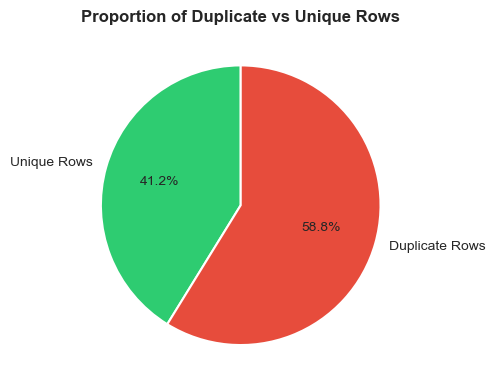

In [14]:
plt.figure(figsize=(5, 4))
labels = ['Unique Rows', 'Duplicate Rows']
sizes = [n_unique_rows, n_duplicates]
colors = ['#2ecc71', '#e74c3c']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Proportion of Duplicate vs Unique Rows')
plt.tight_layout()
plt.show()


**Note:** Given only 250 companies and features that each take just 3 possible values (0, 0.5, 1), a high duplicate rate is *expected* and not necessarily a data-entry error. It should still be kept in mind when splitting data for modeling, to avoid identical rows appearing in both the train and test sets.

## Step 9 — Statistical Summary

**Why:** `.describe()` gives central tendency and spread (mean, std, min, max, quartiles) for numeric features. It is the fastest way to spot obviously wrong values and to understand how scores are distributed on average, before visualizing anything.

In [15]:
df.describe().T.style.background_gradient(cmap='Blues', axis=0)


,count,mean,std,min,25%,50%,75%,max
industrial_risk,250.000000,0.518000,0.411526,0.000000,0.000000,0.500000,1.000000,1.000000
management_risk,250.000000,0.614000,0.410705,0.000000,0.500000,0.500000,1.000000,1.000000
financial_flexibility,250.000000,0.376000,0.401583,0.000000,0.000000,0.500000,0.500000,1.000000
credibility,250.000000,0.470000,0.415682,0.000000,0.000000,0.500000,1.000000,1.000000
competitiveness,250.000000,0.476000,0.440682,0.000000,0.000000,0.500000,1.000000,1.000000
operating_risk,250.000000,0.570000,0.434575,0.000000,0.000000,0.500000,1.000000,1.000000


In [16]:
# Skewness and kurtosis — quantify asymmetry and tail-heaviness of each feature's distribution
feature_cols = ['industrial_risk', 'management_risk', 'financial_flexibility',
                 'credibility', 'competitiveness', 'operating_risk']

shape_stats = pd.DataFrame({
    'skewness': df[feature_cols].skew().round(3),
    'kurtosis': df[feature_cols].kurt().round(3)
})
shape_stats


,skewness,kurtosis
industrial_risk,-0.067,-1.521
management_risk,-0.445,-1.379
financial_flexibility,0.479,-1.290
credibility,0.113,-1.546
competitiveness,0.094,-1.711
operating_risk,-0.276,-1.625


## Step 10 — Validate Expected Value Ranges (Domain Check)

**Why:** The data dictionary states every feature should only take values `{0, 0.5, 1}`. Rather than assuming this is true, we verify it explicitly — real-world exports sometimes contain typos or extra categories, and catching that now avoids a modeling bug discovered much later.

In [17]:
print("Unique values per column (domain check):\n")
for col in df.columns:
    vals = sorted(df[col].unique(), key=str)
    print(f"{col:25s}: {vals}")


Unique values per column (domain check):

industrial_risk          : [0.0, 0.5, 1.0]
management_risk          : [0.0, 0.5, 1.0]
financial_flexibility    : [0.0, 0.5, 1.0]
credibility              : [0.0, 0.5, 1.0]
competitiveness          : [0.0, 0.5, 1.0]
operating_risk           : [0.0, 0.5, 1.0]
class                    : ['bankruptcy', 'non-bankruptcy']


In [18]:
expected_values = {0.0, 0.5, 1.0}
print("Domain validation result:\n")
for col in feature_cols:
    actual = set(df[col].unique())
    ok = actual.issubset(expected_values)
    print(f"{col:25s}: {'PASS - only expected values found' if ok else 'FAIL - unexpected values: ' + str(actual - expected_values)}")


Domain validation result:

industrial_risk          : PASS - only expected values found
management_risk          : PASS - only expected values found
financial_flexibility    : PASS - only expected values found
credibility              : PASS - only expected values found
competitiveness          : PASS - only expected values found
operating_risk           : PASS - only expected values found


## Step 11 — Target Variable Analysis (Class Balance)

**Why:** For a classification problem, the balance of target classes determines which metrics can be trusted — accuracy becomes misleading on heavily imbalanced data, and resampling techniques may be needed. We check both the raw counts and the visual proportion.

In [19]:
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True).round(3) * 100

target_summary = pd.DataFrame({'count': class_counts, 'percentage (%)': class_pct})
target_summary


,count,percentage (%)
class,,
non-bankruptcy,143,57.2
bankruptcy,107,42.8


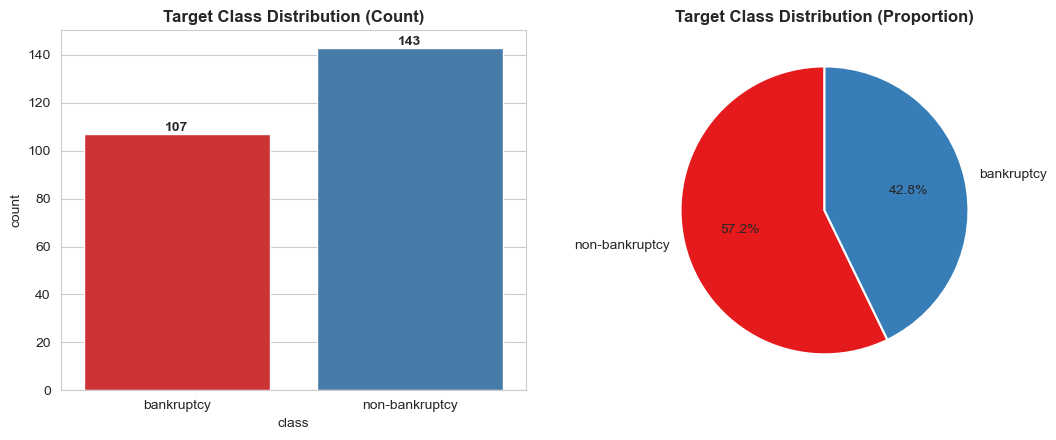

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Count plot
ax = sns.countplot(data=df, x='class', hue='class', palette='Set1', legend=False, ax=axes[0])
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Target Class Distribution (Count)')

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set1', 2), startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Distribution (Proportion)')

plt.tight_layout()
plt.show()


## Step 12 — Encode the Target Variable

**Why:** Correlation analysis and machine learning algorithms require numeric labels. We add a numeric column `class_num` (`bankruptcy=1`, `non-bankruptcy=0`) while keeping the original text column intact for readable plots.

In [21]:
df['class_num'] = df['class'].map({'bankruptcy': 1, 'non-bankruptcy': 0})
df[['class', 'class_num']].drop_duplicates().reset_index(drop=True)


,class,class_num
0,bankruptcy,1
1,non-bankruptcy,0


## Step 13 — Univariate Analysis: Feature Distributions (Count Plots)

**Why:** Each feature is examined individually first, before looking at relationships between variables. Since all six features are **ordinal** (fixed levels 0, 0.5, 1) rather than continuous, count plots are the correct visualization — a histogram/KDE would misleadingly imply continuous data.

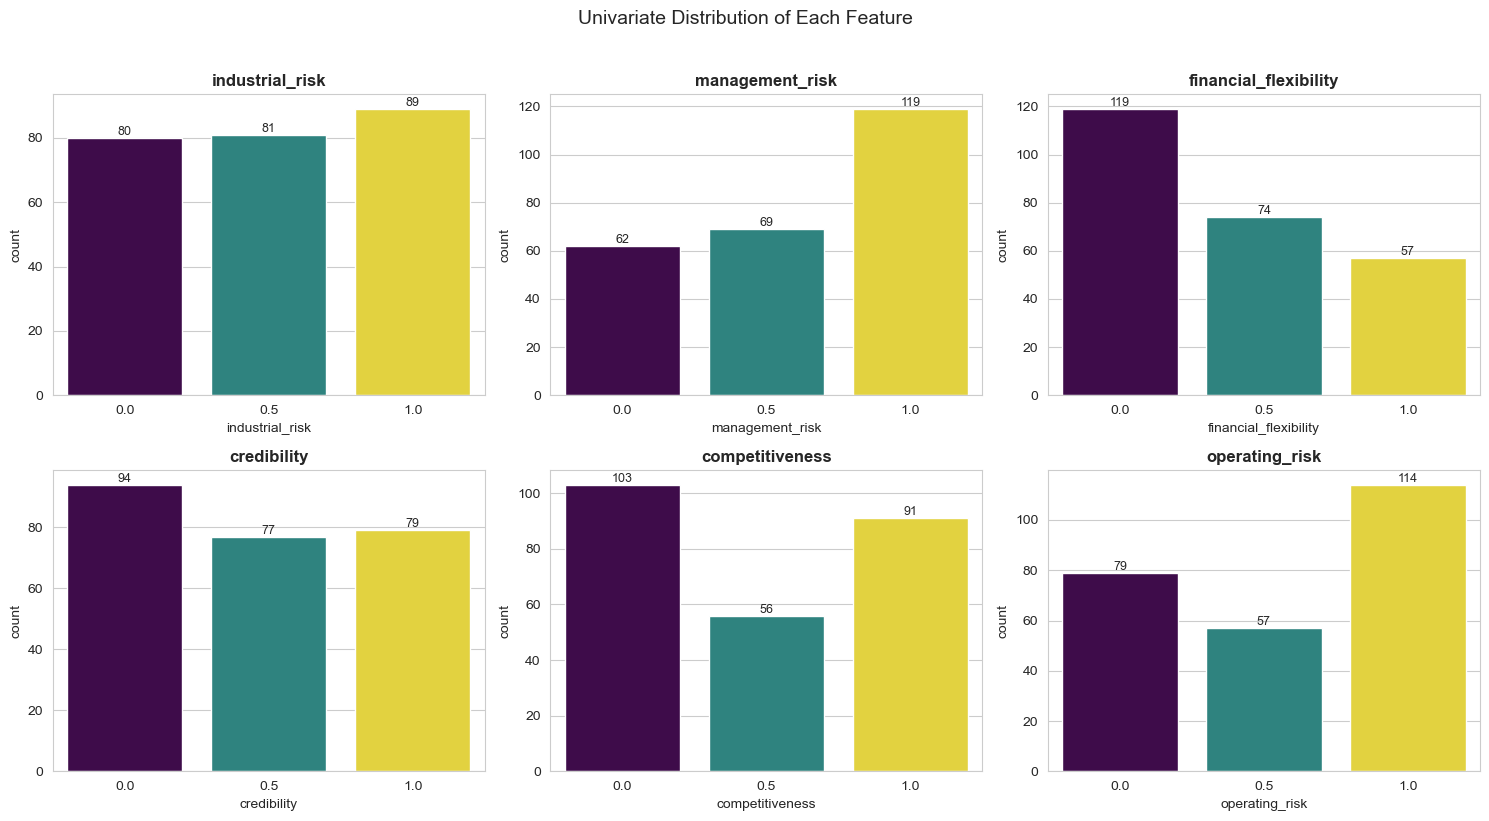

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.countplot(data=df, x=col, hue=col, ax=ax, palette='viridis', legend=False)
    ax.set_title(col)
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Univariate Distribution of Each Feature', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Step 14 — Univariate Analysis: Proportional View (Pie Charts)

**Why:** While count plots show absolute frequency, pie charts make the *proportional* split between low/medium/high levels immediately visible for each feature — useful for quickly spotting which features skew toward one extreme.

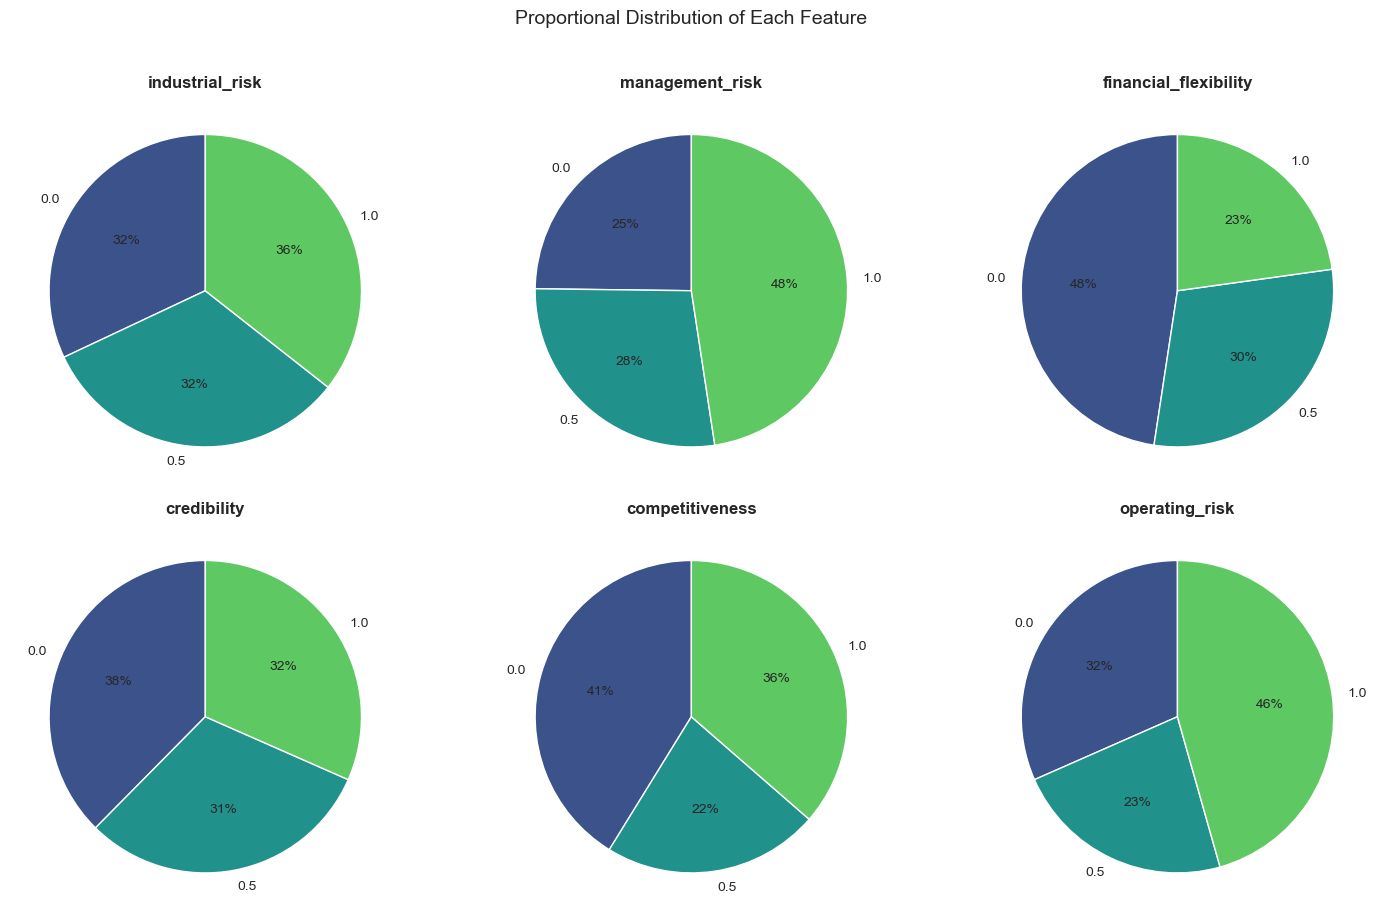

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors = sns.color_palette('viridis', 3)
for ax, col in zip(axes.flatten(), feature_cols):
    vc = df[col].value_counts().sort_index()
    ax.pie(vc, labels=[f'{v}' for v in vc.index], autopct='%1.0f%%',
           colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
    ax.set_title(col)
plt.suptitle('Proportional Distribution of Each Feature', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Step 15 — Bivariate Analysis: Cross-Tabulations (Feature vs Target)

**Why:** This is the core of EDA for a classification problem — does the value of a feature actually differ between bankrupt and non-bankrupt companies? Cross-tabulations quantify this precisely before any chart is drawn.

In [24]:
for col in feature_cols:
    ct = pd.crosstab(df[col], df['class'], normalize='index').round(3) * 100
    print(f"--- {col} vs class (row %) ---")
    display(ct)
    print()


--- industrial_risk vs class (row %) ---


class,bankruptcy,non-bankruptcy
industrial_risk,,
0.0,32.5,67.5
0.5,34.6,65.4
1.0,59.6,40.4



--- management_risk vs class (row %) ---


class,bankruptcy,non-bankruptcy
management_risk,,
0.0,17.7,82.3
0.5,33.3,66.7
1.0,61.3,38.7



--- financial_flexibility vs class (row %) ---


...

class,bankruptcy,non-bankruptcy
credibility,,
0.0,92.6,7.4
0.5,22.1,77.9
1.0,3.8,96.2



--- competitiveness vs class (row %) ---


class,bankruptcy,non-bankruptcy
competitiveness,,
0.0,100.0,0.0
0.5,7.1,92.9
1.0,0.0,100.0



--- operating_risk vs class (row %) ---


class,bankruptcy,non-bankruptcy
operating_risk,,
0.0,24.1,75.9
0.5,42.1,57.9
1.0,56.1,43.9


## Step 16 — Bivariate Analysis: Grouped Bar Charts

**Why:** Visualizing the cross-tabs makes it immediately obvious which features separate the two classes cleanly (bars fully diverge) versus which barely differ (bars stay similar height) — building intuition about likely feature importance before modeling.

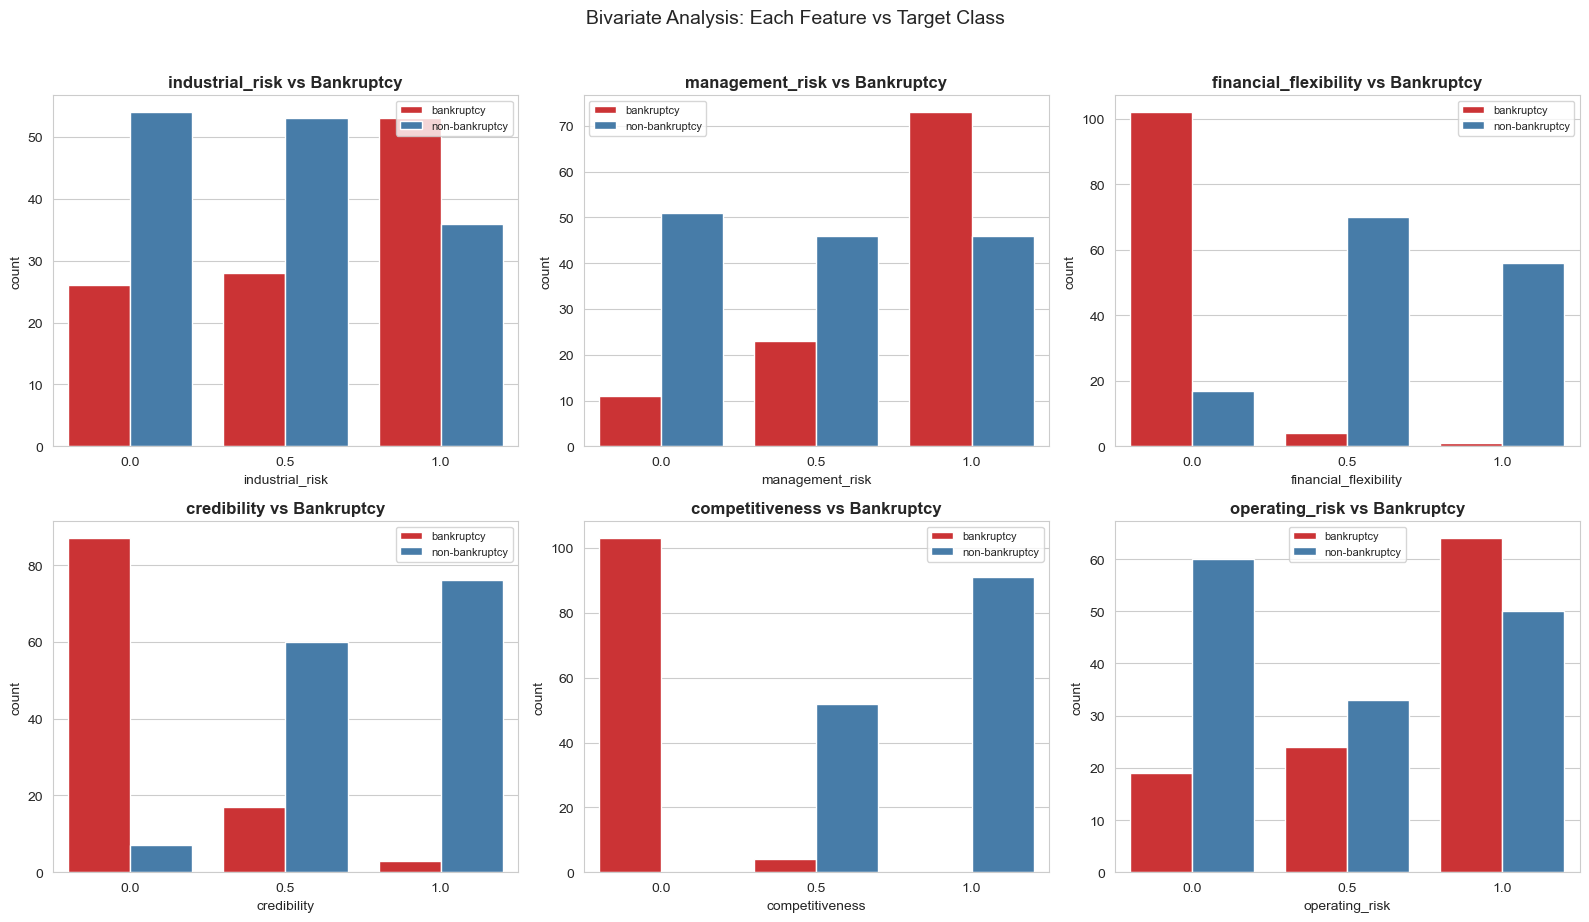

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.countplot(data=df, x=col, hue='class', ax=ax, palette='Set1')
    ax.set_title(f'{col} vs Bankruptcy')
    ax.legend(fontsize=8)
plt.suptitle('Bivariate Analysis: Each Feature vs Target Class', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Step 17 — Outlier Check: Boxplots

**Why:** Boxplots are standard practice for outlier detection. Since every feature here is a bounded ordinal score (only 0, 0.5, or 1 is possible), the classic IQR-based "outlier" concept for continuous measurements doesn't strictly apply — but generating boxplots formally confirms no invalid/extreme values exist, and additionally splitting by class shows how the score spread shifts between bankrupt and non-bankrupt companies.

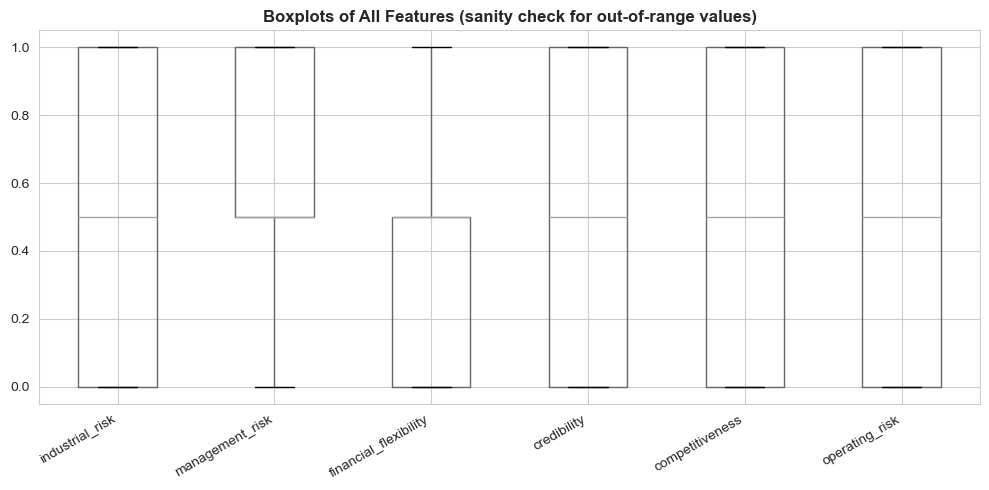

In [26]:
plt.figure(figsize=(10, 5))
df[feature_cols].boxplot()
plt.title('Boxplots of All Features (sanity check for out-of-range values)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


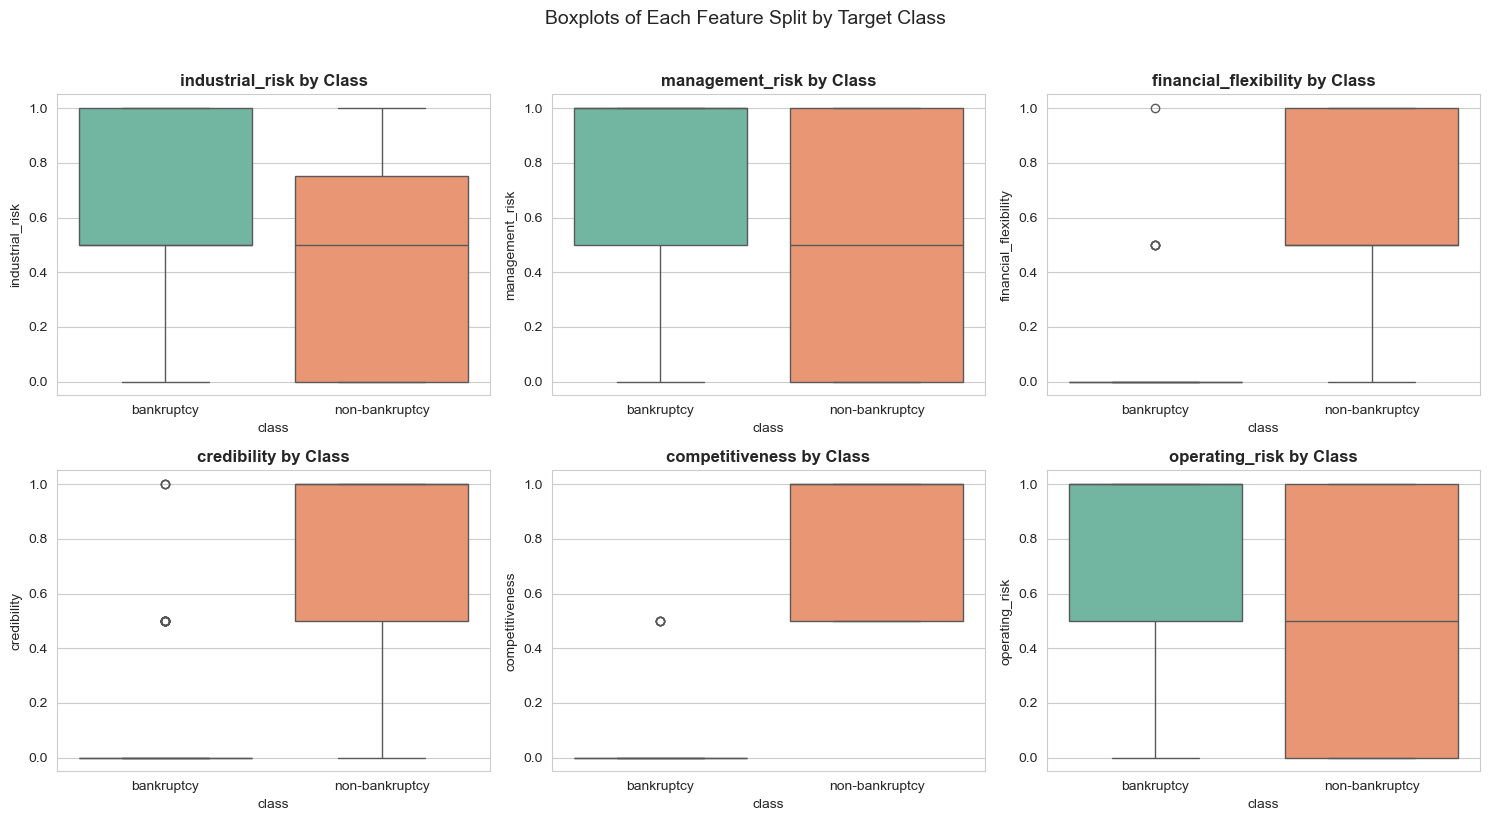

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x='class', y=col, hue='class', ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col} by Class')
plt.suptitle('Boxplots of Each Feature Split by Target Class', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Step 18 — Distribution Shape by Class: Violin Plots

**Why:** Violin plots combine a boxplot with a density estimate, revealing not just the median/quartiles but the full *shape* of each feature's distribution within each class — useful for spotting bimodal patterns that a boxplot alone would hide.

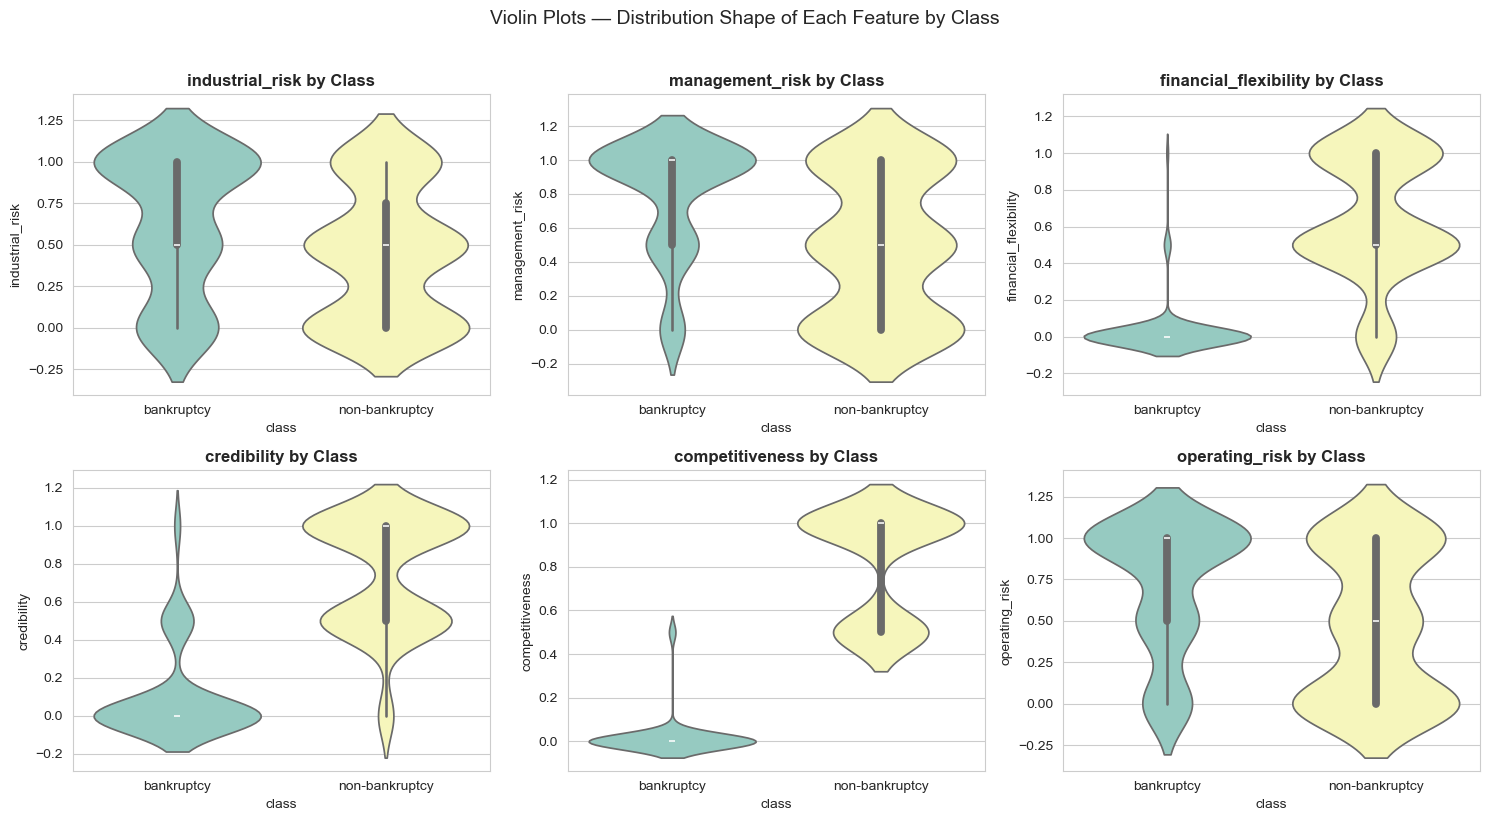

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.violinplot(data=df, x='class', y=col, hue='class', ax=ax, palette='Set3', legend=False)
    ax.set_title(f'{col} by Class')
plt.suptitle('Violin Plots — Distribution Shape of Each Feature by Class', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Step 19 — Correlation Analysis

**Why:** A correlation heatmap quantifies linear relationships between all numeric features (and the encoded target) simultaneously. It helps identify (a) which features correlate most strongly with bankruptcy, and (b) multicollinearity between predictors, which affects models like logistic regression.

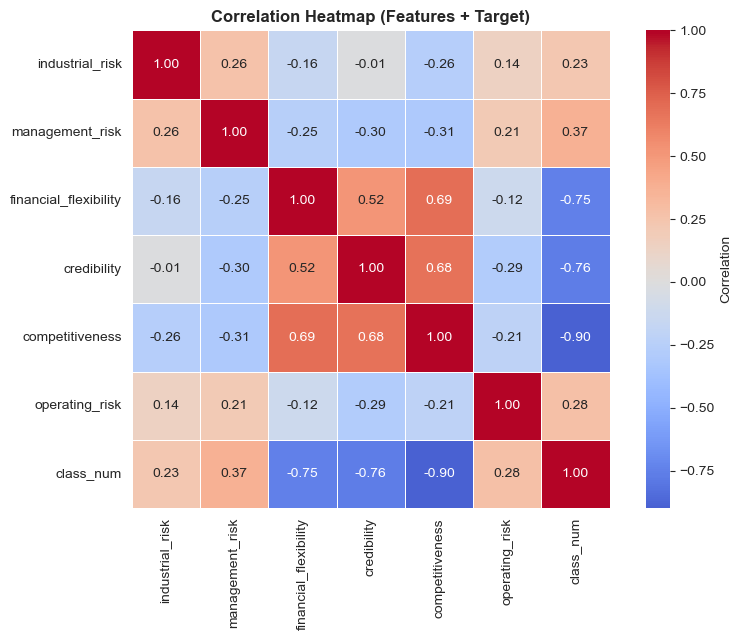

In [29]:
corr = df[feature_cols + ['class_num']].corr().round(2)

plt.figure(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (Features + Target)')
plt.tight_layout()
plt.show()


In [30]:
# Rank features purely by their correlation strength with the target
target_corr = corr['class_num'].drop('class_num').sort_values(key=abs, ascending=False)
print("Feature correlation with bankruptcy (class_num), ranked by strength:\n")
display(target_corr.to_frame('correlation_with_target'))


Feature correlation with bankruptcy (class_num), ranked by strength:



,correlation_with_target
competitiveness,-0.90
credibility,-0.76
financial_flexibility,-0.75
management_risk,0.37
operating_risk,0.28
industrial_risk,0.23


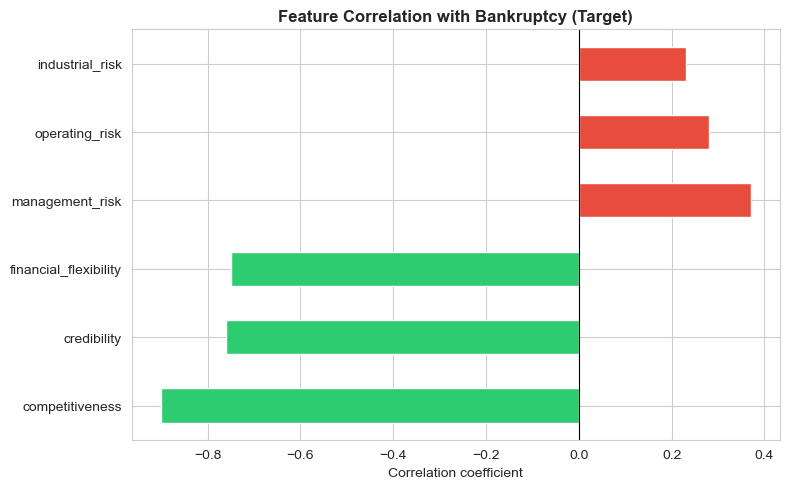

In [31]:
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Bankruptcy (Target)')
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Step 20 — Multivariate Analysis: Pairplot

**Why:** A pairplot lets us visually scan every pairwise feature relationship at once, colored by target class, to spot potential separability that a single model (e.g. logistic regression) could exploit.

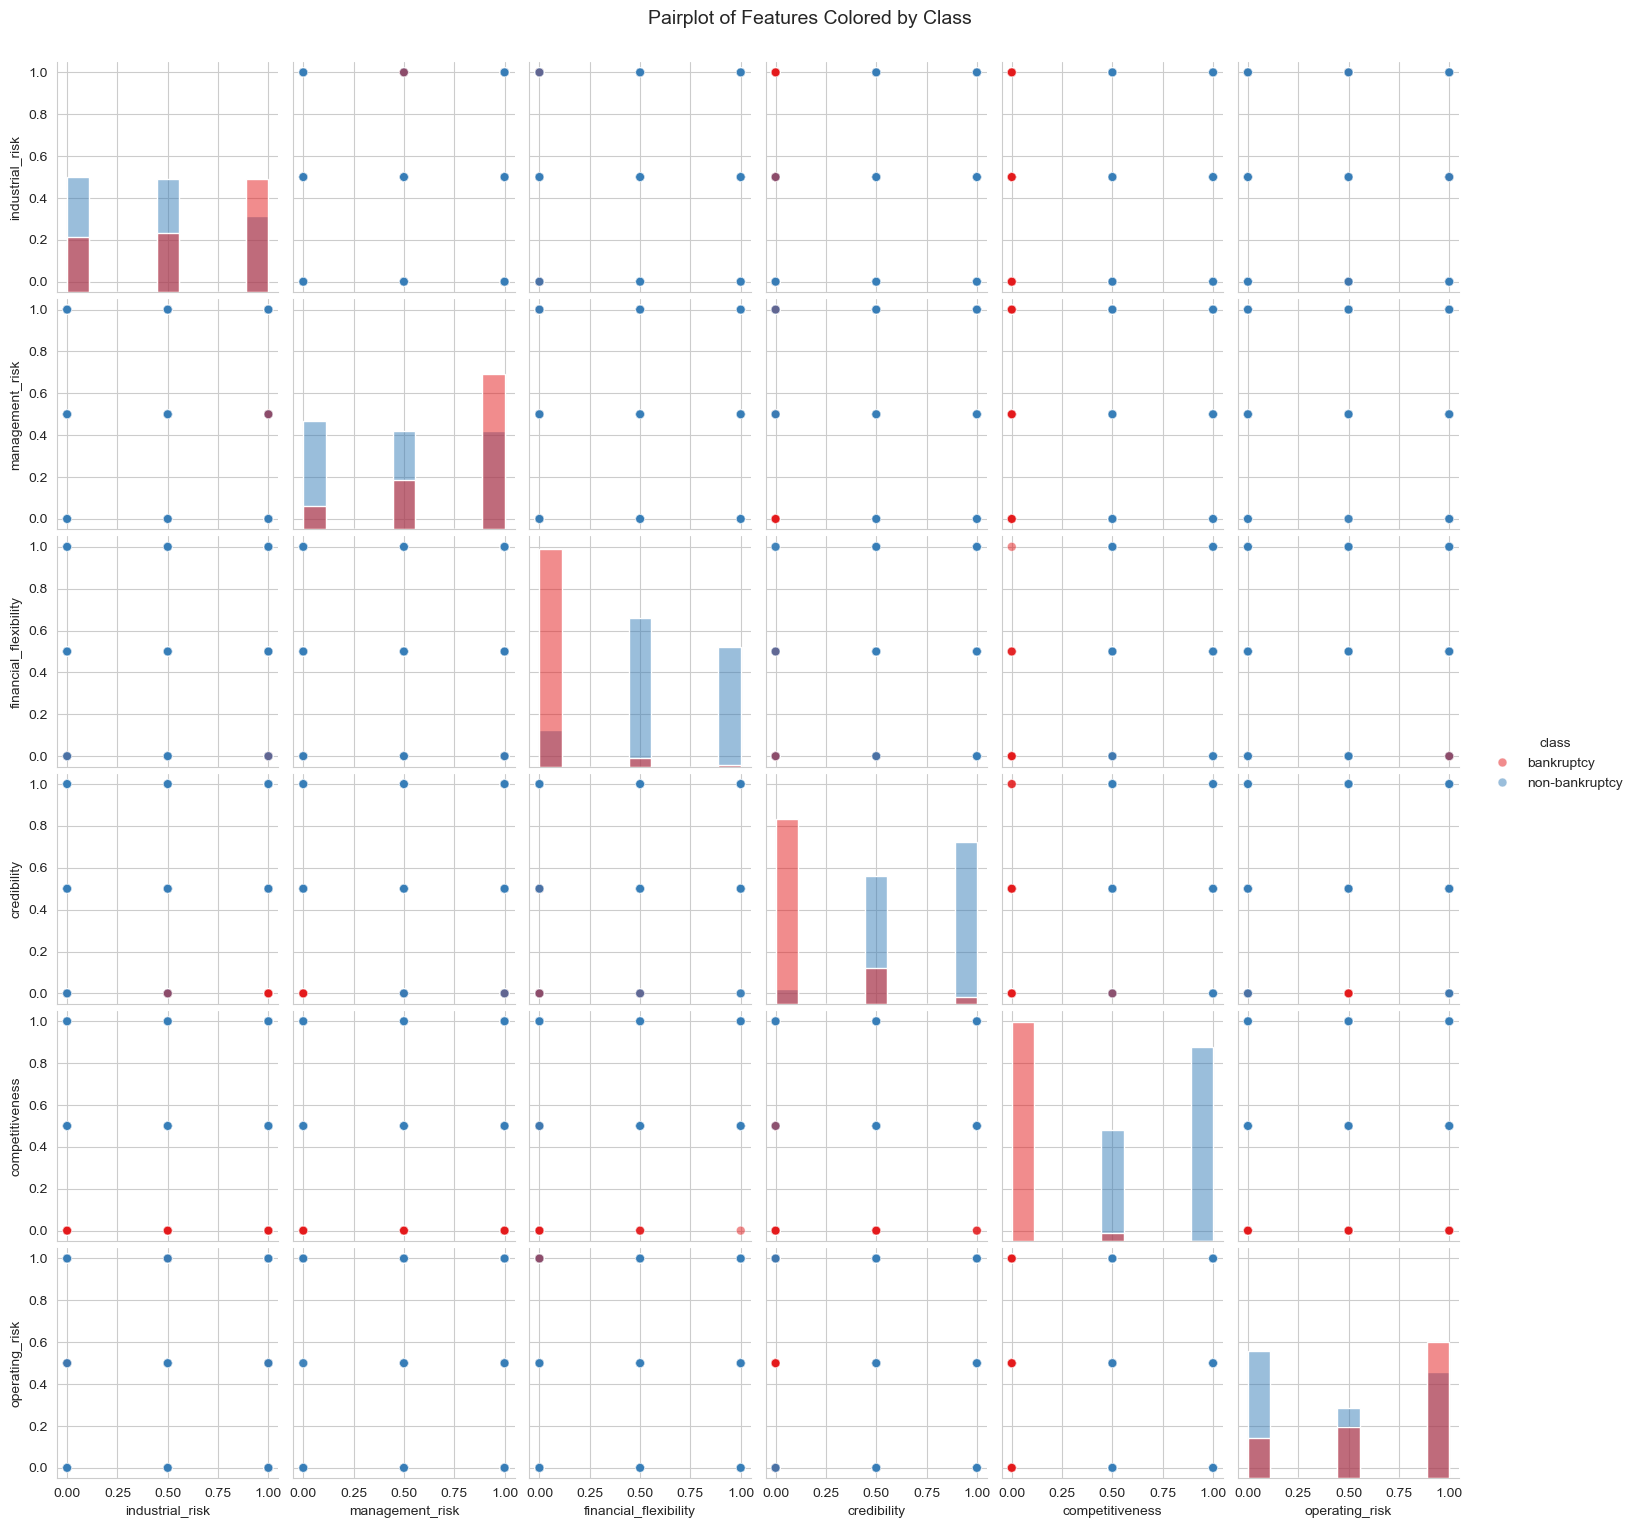

In [32]:
g = sns.pairplot(df[feature_cols + ['class']], hue='class', palette='Set1',
                  plot_kws={'alpha': 0.5, 's': 40}, diag_kind='hist')
g.figure.suptitle('Pairplot of Features Colored by Class', y=1.02, fontsize=14)
plt.show()


## Step 21 — Mean Feature Value by Class

**Why:** Comparing the average score of each feature between the two classes gives a quick, interpretable ranking of which features differ most between bankrupt and non-bankrupt companies — useful intuition for feature importance before modeling.

In [33]:
mean_by_class = df.groupby('class')[feature_cols].mean().round(3)
mean_by_class


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
class,,,,,,
bankruptcy,0.626,0.790,0.028,0.107,0.019,0.710
non-bankruptcy,0.437,0.483,0.636,0.741,0.818,0.465


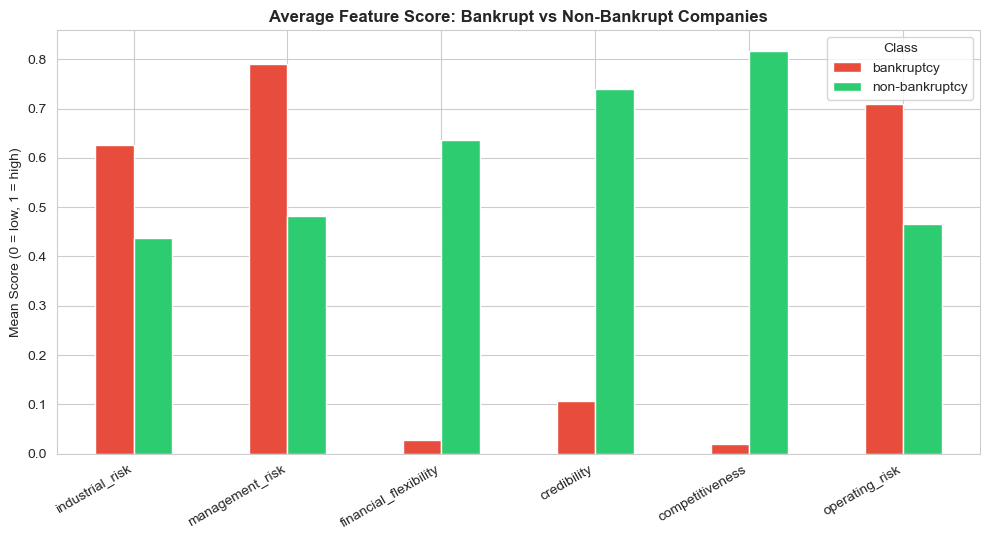

In [34]:
mean_by_class.T.plot(kind='bar', figsize=(10, 5.5), color=['#e74c3c', '#2ecc71'])
plt.title('Average Feature Score: Bankrupt vs Non-Bankrupt Companies')
plt.ylabel('Mean Score (0 = low, 1 = high)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## Step 22 — Multicollinearity Check Among Predictors

**Why:** Beyond correlation with the target, predictors that are highly correlated *with each other* can destabilize coefficient estimates in linear models like logistic regression. We isolate the feature-to-feature correlations (excluding the target) to check for this.

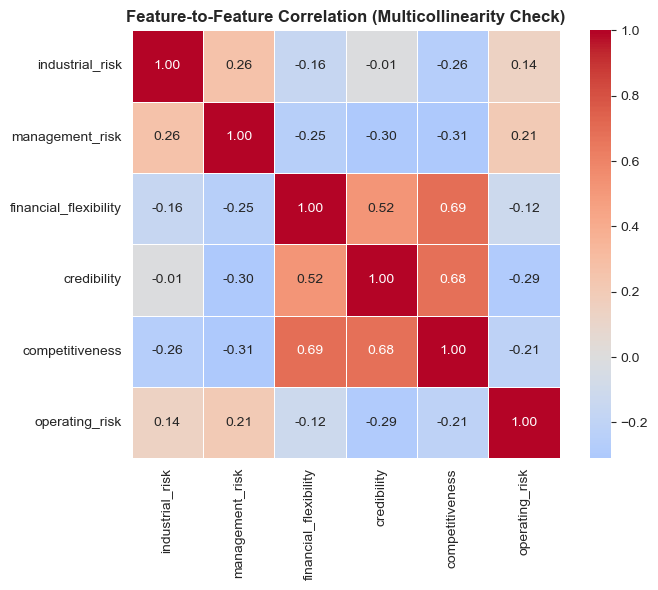

Feature pairs with |correlation| >= 0.5 (potential multicollinearity):

  financial_flexibility     <-> credibility                r = 0.52
  financial_flexibility     <-> competitiveness            r = 0.69
  credibility               <-> competitiveness            r = 0.68


In [35]:
feature_corr = df[feature_cols].corr().round(2)
plt.figure(figsize=(7.5, 6))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature-to-Feature Correlation (Multicollinearity Check)')
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c1, c2 = feature_cols[i], feature_cols[j]
        val = feature_corr.loc[c1, c2]
        if abs(val) >= 0.5:
            high_corr_pairs.append((c1, c2, val))

print("Feature pairs with |correlation| >= 0.5 (potential multicollinearity):\n")
for c1, c2, val in high_corr_pairs:
    print(f"  {c1:25s} <-> {c2:25s}  r = {val}")


## Step 23 — Summary of Key Insights

- **No missing values** and **no invalid/out-of-range values** were found — the dataset is clean and requires minimal preprocessing.
- **Duplicates:** a large share of rows are exact duplicates, which is expected given only 3 possible values per feature across 250 companies — worth accounting for when splitting into train/test sets.
- **Target balance:** mildly imbalanced (roughly 57% non-bankruptcy vs 43% bankruptcy) — accuracy remains usable but should be reported alongside precision, recall, and F1.
- **Strongest predictors:** `competitiveness`, `credibility`, and `financial_flexibility` show very strong, near-linear separability with the target (large negative correlations).
- **Weaker predictors:** `industrial_risk`, `management_risk`, and `operating_risk` show much noisier, weaker relationships with the target.
- **Multicollinearity:** the three strongest predictors are also moderately correlated with each other — worth checking VIF if coefficient interpretability matters for a linear model.

## Recommended Next Steps
1. Encode the target and consider de-duplicating rows before the train/test split.
2. Start with an interpretable baseline model — Logistic Regression or Decision Tree — since the strongest features already show near-linear separability.
3. Use **stratified** train/test splitting to preserve the class ratio in both sets.
4. Report accuracy alongside precision, recall, F1-score, and a confusion matrix given the mild class imbalance.
5. Check VIF among `competitiveness`, `credibility`, and `financial_flexibility` if coefficient interpretability matters.


In [36]:
print(df["class"].value_counts())

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64


In [37]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 250
Duplicate rows: 147


In [38]:
print(df["class"].value_counts())

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64


In [39]:
print(df["class"].value_counts())
print(df["class"].value_counts(normalize=True))

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64
class
non-bankruptcy    0.572
bankruptcy        0.428
Name: proportion, dtype: float64


In [40]:
features = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk"
]

duplicate_groups = (
    df.groupby(features)["class"]
      .nunique()
)

print(duplicate_groups.value_counts())

class
1    103
Name: count, dtype: int64


In [41]:
print("Total rows:", len(df))
print("Unique feature combinations:", df[features].drop_duplicates().shape[0])
print("Exact duplicate rows:", df.duplicated().sum())

Total rows: 250
Unique feature combinations: 103
Exact duplicate rows: 147


In [42]:
combination_counts = df.groupby(features).size()

print(combination_counts.describe())

count    103.000000
mean       2.427184
std        1.839661
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max       11.000000
dtype: float64


In [43]:
print(
    combination_counts
    .sort_values(ascending=False)
    .head(15)
)

industrial_risk  management_risk  financial_flexibility  credibility  competitiveness  operating_risk
0.0              1.0              0.0                    0.0          0.0              1.0               11
1.0              1.0              0.0                    0.0          0.0              1.0               10
                                                                                       0.5                9
0.5              1.0              0.0                    0.0          0.0              1.0                8
                 0.5              0.0                    0.0          0.0              1.0                7
0.0              0.5              0.0                    0.0          0.0              1.0                5
0.5              1.0              0.0                    0.0          0.0              0.5                5
1.0              1.0              0.0                    0.5          0.0              1.0                4
0.0              0.5              

In [44]:
from sklearn.model_selection import GroupShuffleSplit

features = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk"
]

X = df[features]
y = df["class"]

groups = df[features].astype(str).agg("_".join, axis=1)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training groups:", groups.iloc[train_idx].nunique())
print("Testing groups:", groups.iloc[test_idx].nunique())

Training rows: 202
Testing rows: 48
Training groups: 82
Testing groups: 21


In [45]:
print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
class
non-bankruptcy    122
bankruptcy         80
Name: count, dtype: int64

Test class distribution:
class
bankruptcy        27
non-bankruptcy    21
Name: count, dtype: int64


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# XGBoost requires numeric (0/1) labels
y_train_num = (y_train == 'bankruptcy').astype(int)
y_test_num = (y_test == 'bankruptcy').astype(int)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        eval_metric='logloss',
        random_state=42
    ),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == 'XGBoost':
        # XGBoost needs numeric labels; convert predictions back to text for consistent evaluation
        model.fit(X_train_scaled, y_train_num)
        pred_num = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:, 1]
        pred = np.where(pred_num == 1, 'bankruptcy', 'non-bankruptcy')
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:, list(model.classes_).index('bankruptcy')]

    fitted_models[name] = model
    predictions[name] = pred
    probabilities[name] = prob

print("Models trained:", list(models.keys()))


Models trained: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM', 'KNN']


In [49]:
pred_preview = pd.DataFrame(predictions)
pred_preview['actual'] = y_test.values
pred_preview.head(10)


,Logistic Regression,Decision Tree,Random Forest,XGBoost,SVM,KNN,actual
0,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
1,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
2,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
3,bankruptcy,non-bankruptcy,non-bankruptcy,non-bankruptcy,bankruptcy,bankruptcy,bankruptcy
4,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
5,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
6,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
7,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
8,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy
9,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy,bankruptcy


Next is Evaluation part for all 6 models!!


Model                   Accuracy   Precision    Recall  F1-score
Logistic Regression         1.00        1.00      1.00      1.00
SVM                         1.00        1.00      1.00      1.00
KNN                         1.00        1.00      1.00      1.00
Decision Tree               0.92        1.00      0.85      0.92
Random Forest               0.92        1.00      0.85      0.92
XGBoost                     0.92        1.00      0.85      0.92

Full comparison (includes ROC-AUC), sorted by F1-score:



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
SVM,1.000000,1.000000,1.000000,1.000000,1.000000
KNN,1.000000,1.000000,1.000000,1.000000,1.000000
Decision Tree,0.920000,1.000000,0.850000,0.920000,0.930000
Random Forest,0.920000,1.000000,0.850000,0.920000,1.000000
XGBoost,0.920000,1.000000,0.850000,0.920000,0.930000


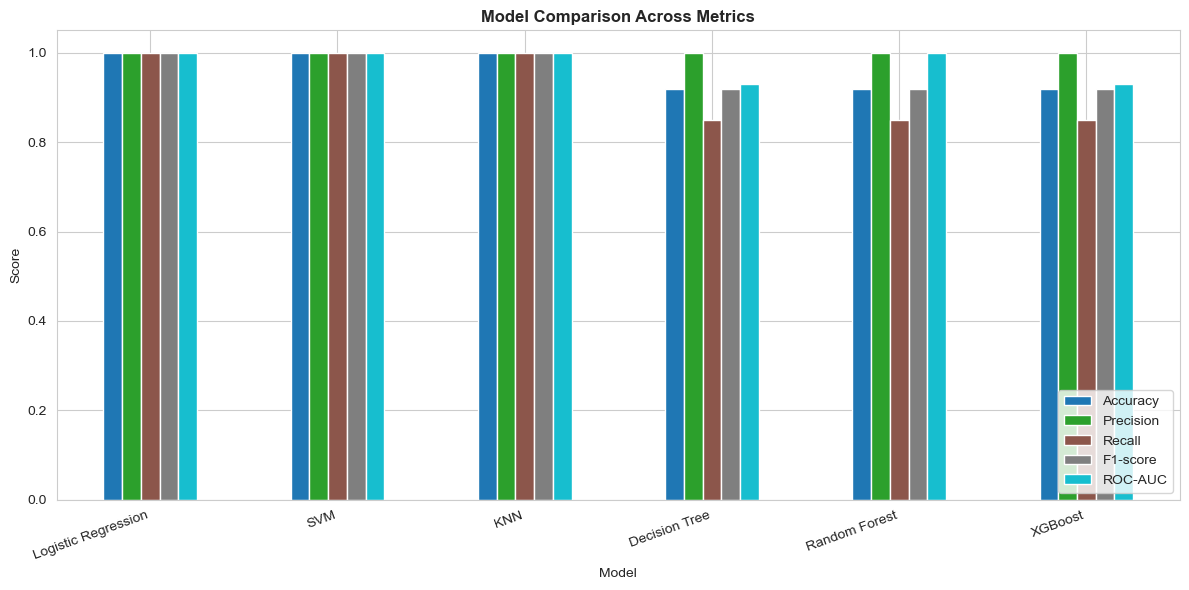

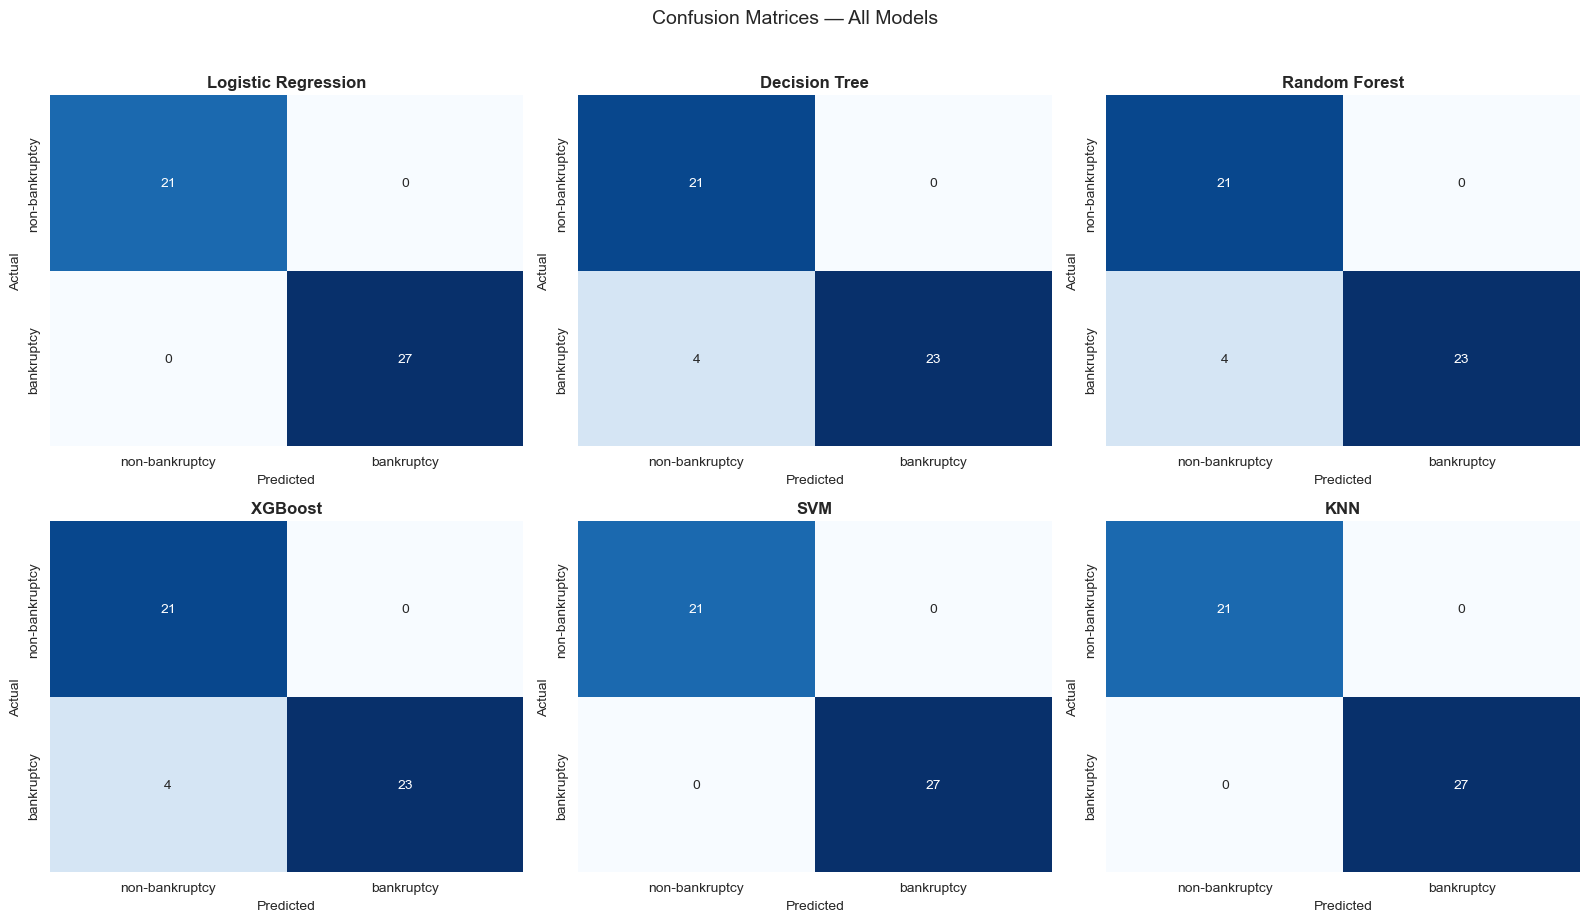

--- Logistic Regression ---
                precision    recall  f1-score   support

non-bankruptcy       1.00      1.00      1.00        21
    bankruptcy       1.00      1.00      1.00        27

      accuracy                           1.00        48
     macro avg       1.00      1.00      1.00        48
  weighted avg       1.00      1.00      1.00        48

--- Decision Tree ---
                precision    recall  f1-score   support

non-bankruptcy       0.84      1.00      0.91        21
    bankruptcy       1.00      0.85      0.92        27

      accuracy                           0.92        48
     macro avg       0.92      0.93      0.92        48
  weighted avg       0.93      0.92      0.92        48

--- Random Forest ---
                precision    recall  f1-score   support

non-bankruptcy       0.84      1.00      0.91        21
    bankruptcy       1.00      0.85      0.92        27

      accuracy                           0.92        48
     macro avg       0.9

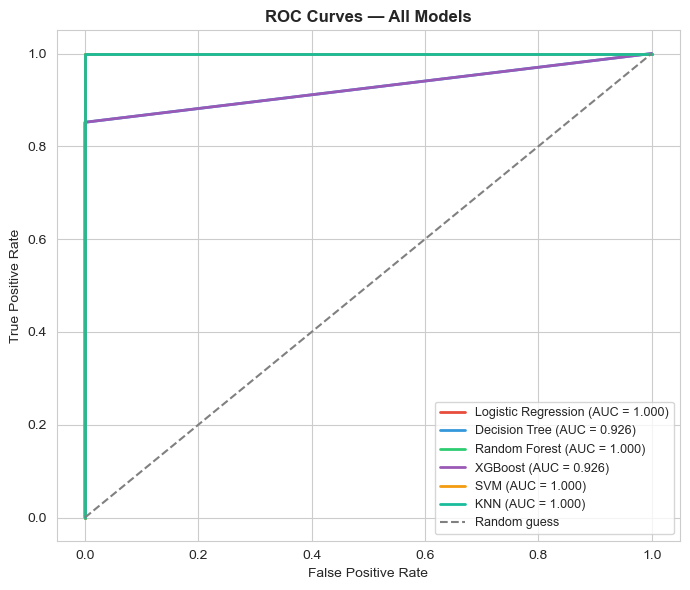

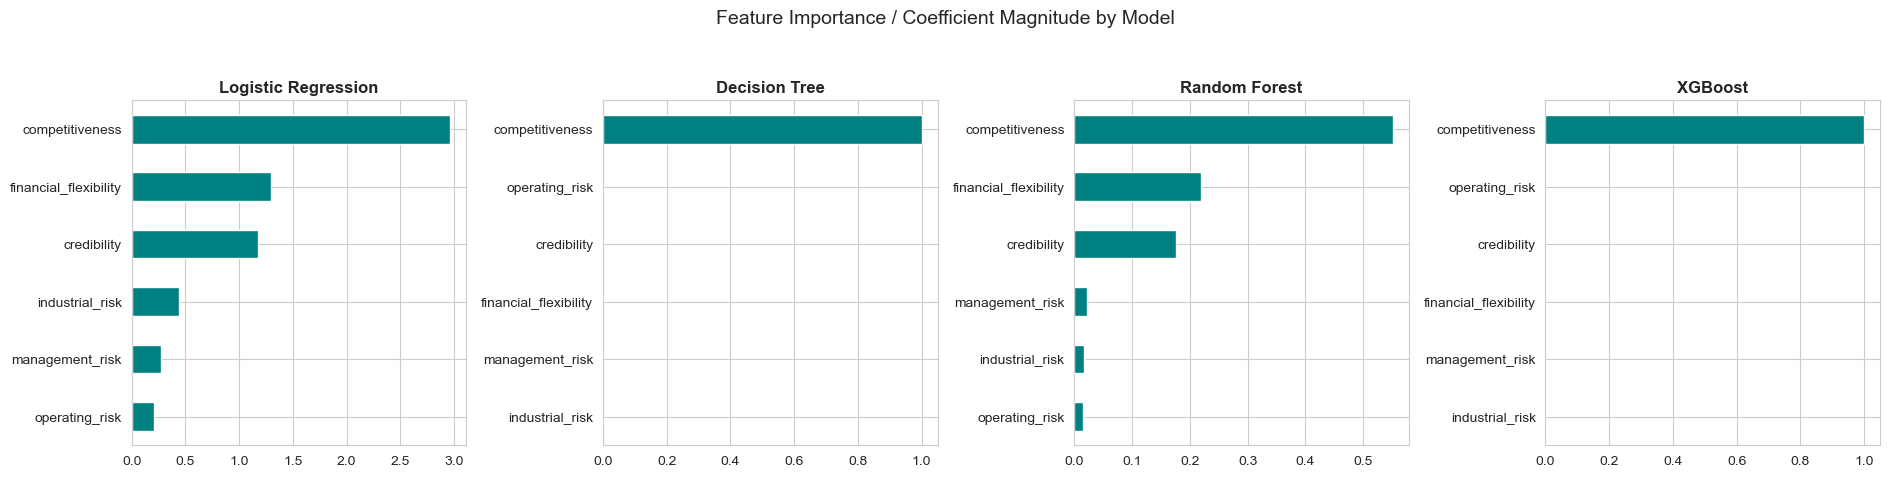


Best model by F1-score: Logistic Regression
Best model by ROC-AUC:  Logistic Regression


In [50]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

pos_label = 'bankruptcy'
labels_order = ['non-bankruptcy', 'bankruptcy']
y_test_binary = (y_test == pos_label).astype(int)

# Metrics comparison table (Accuracy, Precision, Recall, F1, ROC-AUC) ----
results = []
for name in models:
    pred = predictions[name]
    prob = probabilities[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, pos_label=pos_label),
        'Recall': recall_score(y_test, pred, pos_label=pos_label),
        'F1-score': f1_score(y_test, pred, pos_label=pos_label),
        'ROC-AUC': roc_auc_score(y_test_binary, prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(2)
results_df_sorted = results_df.sort_values('F1-score', ascending=False)

# Plain printed table (Model | Accuracy | Precision | Recall | F1-score)
print(f"{'Model':<22}{'Accuracy':>10}{'Precision':>12}{'Recall':>10}{'F1-score':>10}")
for name, row in results_df_sorted.iterrows():
    print(f"{name:<22}{row['Accuracy']:>10.2f}{row['Precision']:>12.2f}{row['Recall']:>10.2f}{row['F1-score']:>10.2f}")

print()
print("Full comparison (includes ROC-AUC), sorted by F1-score:\n")
display(results_df_sorted.style.background_gradient(cmap='Greens', axis=0))

#  Bar chart comparing all metrics across models ----
results_df_sorted.plot(kind='bar', figsize=(12, 6), colormap='tab10')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#  Confusion matrices for each model ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, predictions[name], labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_order, yticklabels=labels_order, cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Models', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#  Classification reports ----
for name in models:
    print(f"--- {name} ---")
    print(classification_report(y_test, predictions[name], labels=labels_order))

# ROC curves — all models 
plt.figure(figsize=(7, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
for (name, prob), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_binary, prob)
    auc = roc_auc_score(y_test_binary, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

#  Feature importance for tree-based 
importance_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, name in zip(axes, importance_models):
    model = fitted_models[name]
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=features)
    else:
        # Logistic Regression: use absolute coefficient magnitude instead
        importances = pd.Series(np.abs(model.coef_[0]), index=features)
    importances.sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{name}')
plt.suptitle('Feature Importance / Coefficient Magnitude by Model', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBest model by F1-score: {results_df_sorted.index[0]}")
print(f"Best model by ROC-AUC:  {results_df_sorted.sort_values('ROC-AUC', ascending=False).index[0]}")


In [52]:
# To deploy we are considering Logistic Regression
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)

LogisticRegression()

In [53]:
import pickle

file = 'Bankruptcy_Prevention.pkl'    # Define a file name
pickle.dump(log_reg, open(file, 'wb'))  # Save the trained model to a pickle file
print("Model saved as Bankruptcy_Prevention.pkl")

Model saved as Bankruptcy_Prevention.pkl
